# GSM8K EDA

phase01 difficulty verification — 다운로드한 GSM8K test split 탐색.

- 데이터: `data/gsm8k_test.jsonl` (1,319 examples)
- 컬럼: `question`, `answer`
- `answer`는 풀이 과정 + `<<계산식>>` 주석 + `#### 최종정답` 형태

In [1]:
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 200)
DATA_PATH = "data/gsm8k_test.jsonl"

## 1. 로드 및 기본 정보

In [2]:
records = [json.loads(line) for line in open(DATA_PATH, encoding="utf-8")]
df = pd.DataFrame(records)

print("num examples:", len(df))
print("columns     :", list(df.columns))
print("nulls       :\n", df.isna().sum())
print("duplicated questions:", df["question"].duplicated().sum())
df.head(3)

num examples: 1319
columns     : ['question', 'answer']
nulls       :
 question    0
answer      0
dtype: int64
duplicated questions: 0


,question,answer
0,Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per...,Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.\nShe makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.\n#### 18
1,A robe takes 2 bolts of blue fiber and half that much white fiber. How many bolts in total does it take?,It takes 2/2=<<2/2=1>>1 bolt of white fiber\nSo the total amount of fabric is 2+1=<<2+1=3>>3 bolts of fabric\n#### 3
2,"Josh decides to try flipping a house. He buys a house for $80,000 and then puts in $50,000 in repairs. This increased the value of the house by 150%. How much profit did he make?","The cost of the house and repairs came out to 80,000+50,000=$<<80000+50000=130000>>130,000\nHe increased the value of the house by 80,000*1.5=<<80000*1.5=120000>>120,000\nSo the new value of the h..."


## 2. 파생 피처 추출

- `final_answer`: `#### N` 에서 추출한 최종 정답
- `q_char_len` / `q_word_len`: 질문 길이
- `n_reasoning_steps`: 풀이 줄 수 (`####` 줄 제외)
- `n_calc_ops`: `<<...>>` 계산 주석 개수

In [3]:
def extract_final_answer(ans: str):
    if "####" in ans:
        tail = ans.split("####")[-1].strip().replace(",", "")
        m = re.search(r"-?\d+\.?\d*", tail)
        return float(m.group()) if m else np.nan
    return np.nan

def n_reasoning_steps(ans: str):
    lines = [l for l in ans.split("\n") if l.strip() and not l.strip().startswith("####")]
    return len(lines)

df["final_answer"]      = df["answer"].apply(extract_final_answer)
df["q_char_len"]        = df["question"].str.len()
df["q_word_len"]        = df["question"].str.split().apply(len)
df["a_char_len"]        = df["answer"].str.len()
df["n_reasoning_steps"] = df["answer"].apply(n_reasoning_steps)
df["n_calc_ops"]        = df["answer"].str.count(r"<<")
df["n_question_marks"]  = df["question"].str.count(r"\?")

df[["q_char_len", "q_word_len", "a_char_len", "n_reasoning_steps", "n_calc_ops", "final_answer"]].describe()

,q_char_len,q_word_len,a_char_len,n_reasoning_steps,n_calc_ops,final_answer
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1.319000e+03
mean,239.871114,46.250948,292.880970,3.653525,3.246399,6.830316e+03
std,97.607728,18.073655,141.819256,1.462392,1.408548,9.183809e+04
min,73.000000,15.000000,48.000000,2.000000,0.000000,-1.000000e+01
25%,168.000000,33.000000,187.000000,3.000000,2.000000,1.300000e+01
50%,222.000000,43.000000,270.000000,3.000000,3.000000,4.200000e+01
75%,291.000000,55.000000,367.500000,4.000000,4.000000,1.600000e+02
max,848.000000,164.000000,1070.000000,11.000000,8.000000,2.880000e+06


## 3. 길이 분포 시각화

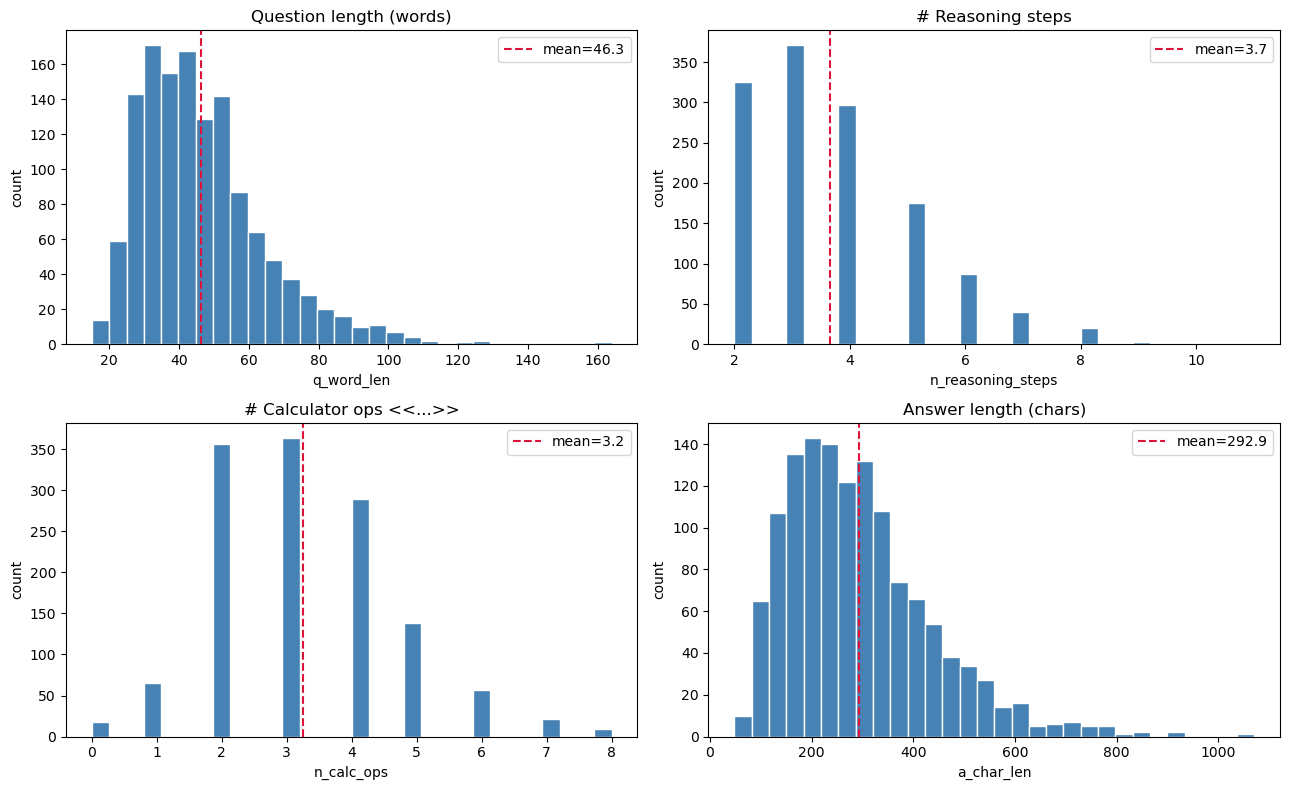

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
specs = [
    ("q_word_len",        "Question length (words)"),
    ("n_reasoning_steps", "# Reasoning steps"),
    ("n_calc_ops",        "# Calculator ops <<...>>"),
    ("a_char_len",        "Answer length (chars)"),
]
for ax, (col, title) in zip(axes.ravel(), specs):
    ax.hist(df[col], bins=30, color="steelblue", edgecolor="white")
    ax.axvline(df[col].mean(), color="crimson", ls="--", lw=1.5, label=f"mean={df[col].mean():.1f}")
    ax.set_title(title); ax.set_xlabel(col); ax.set_ylabel("count"); ax.legend()
plt.tight_layout(); plt.show()

## 4. 추론 단계 수(난이도 proxy) 분석

`n_reasoning_steps`와 `n_calc_ops`는 문제의 본질적 복잡도 proxy로 볼 수 있다.
phase01의 Easy/Hard 라벨(모델 rollout 정답률 기반)과 비교할 때 참고용.

In [5]:
print("reasoning steps value counts:")
print(df["n_reasoning_steps"].value_counts().sort_index())
print("\ncalc ops value counts:")
print(df["n_calc_ops"].value_counts().sort_index())

# 질문 길이 vs 추론 단계 수 상관
print("\ncorrelation (q_word_len vs n_reasoning_steps):",
      round(df["q_word_len"].corr(df["n_reasoning_steps"]), 3))

reasoning steps value counts:
n_reasoning_steps
2     326
3     371
4     297
5     175
6      87
7      40
8      20
9       2
11      1
Name: count, dtype: int64

calc ops value counts:
n_calc_ops
0     18
1     65
2    357
3    364
4    290
5    138
6     57
7     21
8      9
Name: count, dtype: int64

correlation (q_word_len vs n_reasoning_steps): 0.336


## 5. 최종 정답(final_answer) 분포

final answer 추출 실패(NaN): 0
count    1.319000e+03
mean     6.830316e+03
std      9.183809e+04
min     -1.000000e+01
25%      1.300000e+01
50%      4.200000e+01
75%      1.600000e+02
max      2.880000e+06
Name: final_answer, dtype: float64


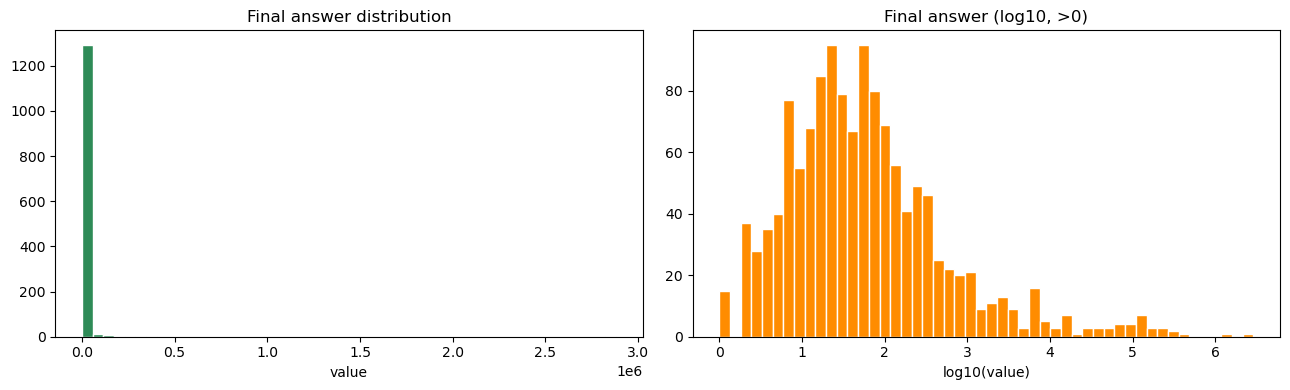

In [6]:
print("final answer 추출 실패(NaN):", df["final_answer"].isna().sum())
print(df["final_answer"].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["final_answer"].dropna(), bins=50, color="seagreen", edgecolor="white")
axes[0].set_title("Final answer distribution"); axes[0].set_xlabel("value")

# 큰 값에 long tail → log 스케일로도 확인
vals = df["final_answer"].dropna()
vals = vals[vals > 0]
axes[1].hist(np.log10(vals), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Final answer (log10, >0)"); axes[1].set_xlabel("log10(value)")
plt.tight_layout(); plt.show()

## 6. 샘플 살펴보기 (길이별)

In [7]:
def show(row):
    print("=" * 80)
    print(f"[steps={row.n_reasoning_steps}, calc_ops={row.n_calc_ops}, ans={row.final_answer}]")
    print("Q:", row.question)
    print("-" * 40)
    print("A:", row.answer)

print("### 가장 짧은(단순) 문제")
show(df.loc[df["n_reasoning_steps"].idxmin()])
print("\n\n### 가장 긴(복잡) 문제")
show(df.loc[df["n_reasoning_steps"].idxmax()])

### 가장 짧은(단순) 문제
[steps=2, calc_ops=2, ans=18.0]
Q: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
----------------------------------------
A: Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.
She makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.
#### 18


### 가장 긴(복잡) 문제
[steps=11, calc_ops=5, ans=13.0]
Q: There is one set of twins and one set of triplets. One twin is 7 years older than one triplet. If their combined ages are 44, how old is one of the twins?
----------------------------------------
A: Let T = age of triplet
Twin's age = T + <<+7=7>>7
Twin's combined age = 2 * (T + 7)
Triplet's combined age = <<3=3>>3T
2 * (T + 7) + 3T = 44
2T + 14 + 3T = 44
5T + 14 = 44
5T = 30
T = <<6=6>>6
Twin = 6 + 7 = <<6+7=13>>13
The twins are each 

## 7. 요약 저장 (선택)

파생 피처가 붙은 테이블을 csv로 저장해 두면 이후 분석에서 재사용 가능.

In [ ]:
# out_cols = ["question", "final_answer", "q_word_len", "a_char_len", "n_reasoning_steps", "n_calc_ops"]
# df[out_cols].to_csv("data/gsm8k_eda_features.csv", index=False)
# print("saved -> data/gsm8k_eda_features.csv")

saved -> data/gsm8k_eda_features.csv
